<a href="https://colab.research.google.com/github/Aryansinghparmar2321/OSSLab_241B048/blob/main/LAB_3(OSS).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("\nFirst 5 rows:")
print(X.head())

Dataset shape: (569, 30)

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst 

In [27]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values:")
print(X.isnull().sum().sum())

Number of samples: 569
Number of features: 30

Target distribution:
target
1    357
0    212
Name: count, dtype: int64

Missing values:
0


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training samples: 455
Testing samples: 114
Training data shape: (455, 30)
Testing data shape: (114, 30)


In [29]:
baseline_model = LogisticRegression(max_iter=2000)

baseline_model.fit(
    X_train_scaled,
    y_train
)

baseline_pred = baseline_model.predict(
    X_test_scaled
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

print("Baseline Accuracy:",
      baseline_accuracy)

Baseline Accuracy: 0.9824561403508771


In [30]:
def fitness_function(position):

    selected = position > 0.5

    if not np.any(selected):
        return 0

    X_selected = X_train_scaled[:, selected]

    model = LogisticRegression(max_iter=2000)

    model.fit(
        X_selected,
        y_train
    )

    predictions = model.predict(X_selected)

    accuracy = accuracy_score(
        y_train,
        predictions
    )

    return accuracy

In [31]:
from sklearn.model_selection import cross_val_score

def fitness_function(position):

    selected = position > 0.5

    if not np.any(selected):
        return 0

    X_selected = X_train_scaled[:, selected]

    model = LogisticRegression(max_iter=2000)

    scores = cross_val_score(
        model,
        X_selected,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    return scores.mean()

In [32]:
n_particles = 15
n_features = X_train_scaled.shape[1]

n_iterations = 30

w = 0.7
c1 = 1.5
c2 = 1.5

np.random.seed(42)

positions = np.random.rand(
    n_particles,
    n_features
)

velocities = np.random.uniform(
    -1,
    1,
    size=(n_particles, n_features)
)

In [33]:
pbest_positions = positions.copy()

pbest_scores = np.array([
    fitness_function(position)
    for position in positions
])

best_index = np.argmax(pbest_scores)

gbest_position = pbest_positions[
    best_index
].copy()

gbest_score = pbest_scores[
    best_index
]

print("Initial Best Fitness:",
      gbest_score)

Initial Best Fitness: 0.9780219780219781


In [34]:
history = []

for iteration in range(n_iterations):

    for i in range(n_particles):

        r1 = np.random.rand(n_features)
        r2 = np.random.rand(n_features)

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (
                pbest_positions[i] - positions[i]
            )
            + c2 * r2 * (
                gbest_position - positions[i]
            )
        )

        positions[i] = (
            positions[i] + velocities[i]
        )

        positions[i] = np.clip(
            positions[i],
            0,
            1
        )

        score = fitness_function(
            positions[i]
        )

        if score > pbest_scores[i]:

            pbest_scores[i] = score

            pbest_positions[i] = (
                positions[i].copy()
            )

        if score > gbest_score:

            gbest_score = score

            gbest_position = (
                positions[i].copy()
            )

    history.append(gbest_score)

    print(
        f"Iteration {iteration + 1:02d} "
        f"| Best Fitness = {gbest_score:.4f}"
    )

Iteration 01 | Best Fitness = 0.9802
Iteration 02 | Best Fitness = 0.9846
Iteration 03 | Best Fitness = 0.9846
Iteration 04 | Best Fitness = 0.9846
Iteration 05 | Best Fitness = 0.9846
Iteration 06 | Best Fitness = 0.9846
Iteration 07 | Best Fitness = 0.9846
Iteration 08 | Best Fitness = 0.9846
Iteration 09 | Best Fitness = 0.9846
Iteration 10 | Best Fitness = 0.9846
Iteration 11 | Best Fitness = 0.9846
Iteration 12 | Best Fitness = 0.9846
Iteration 13 | Best Fitness = 0.9846
Iteration 14 | Best Fitness = 0.9846
Iteration 15 | Best Fitness = 0.9846
Iteration 16 | Best Fitness = 0.9868
Iteration 17 | Best Fitness = 0.9868
Iteration 18 | Best Fitness = 0.9868
Iteration 19 | Best Fitness = 0.9868
Iteration 20 | Best Fitness = 0.9868
Iteration 21 | Best Fitness = 0.9868
Iteration 22 | Best Fitness = 0.9868
Iteration 23 | Best Fitness = 0.9868
Iteration 24 | Best Fitness = 0.9868
Iteration 25 | Best Fitness = 0.9868
Iteration 26 | Best Fitness = 0.9868
Iteration 27 | Best Fitness = 0.9868
I

In [35]:
import matplotlib.pyplot as plt

In [36]:
best_features_mask = gbest_position > 0.5

selected_feature_names = X.columns[
    best_features_mask
]

print("Selected Features:")

for feature in selected_feature_names:
    print(feature)

print(
    "\nNumber of selected features:",
    len(selected_feature_names)
)

print(
    "Best CV Accuracy:",
    gbest_score
)

Selected Features:
mean radius
mean perimeter
mean area
texture error
perimeter error
area error
concave points error
fractal dimension error
worst texture
worst area
worst smoothness
worst compactness
worst symmetry

Number of selected features: 13
Best CV Accuracy: 0.9868131868131869


In [37]:
X_train_pso = X_train_scaled[
    :,
    best_features_mask
]

X_test_pso = X_test_scaled[
    :,
    best_features_mask
]

final_model = LogisticRegression(
    max_iter=2000
)

final_model.fit(
    X_train_pso,
    y_train
)

final_pred = final_model.predict(
    X_test_pso
)

In [38]:
accuracy = accuracy_score(
    y_test,
    final_pred
)

precision = precision_score(
    y_test,
    final_pred
)

recall = recall_score(
    y_test,
    final_pred
)

f1 = f1_score(
    y_test,
    final_pred
)

print("PSO + Logistic Regression")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

PSO + Logistic Regression
-------------------------
Accuracy : 0.956140350877193
Precision: 0.9855072463768116
Recall   : 0.9444444444444444
F1 Score : 0.9645390070921985


In [39]:
cm = confusion_matrix(
    y_test,
    final_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 4 68]]


In [40]:
print("Performance Comparison")
print("----------------------")

print("All Features:")
print("Number of Features:", X.shape[1])
print("Accuracy:", baseline_accuracy)

print("\nPSO Selected Features:")
print(
    "Number of Features:",
    len(selected_feature_names)
)
print("Accuracy:", accuracy)

Performance Comparison
----------------------
All Features:
Number of Features: 30
Accuracy: 0.9824561403508771

PSO Selected Features:
Number of Features: 13
Accuracy: 0.956140350877193


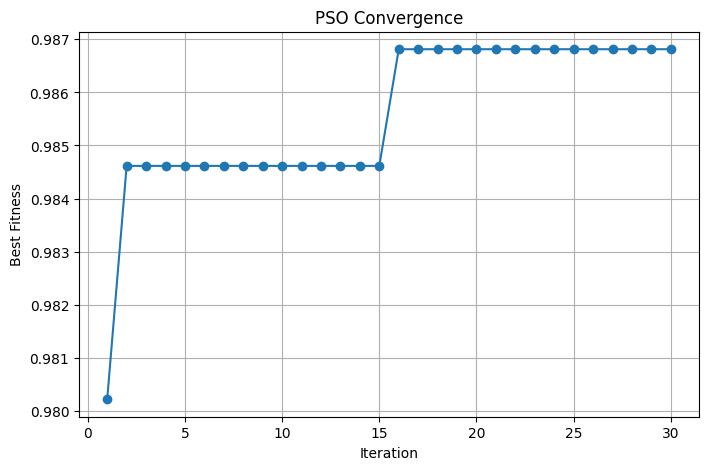

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(history) + 1),
    history,
    marker='o'
)

plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.title("PSO Convergence")
plt.grid(True)

plt.show()